# Energy Consumption Comparison: Prefill Phase

This notebook visualizes the **GPU energy consumption** during the prefill (prompt processing) phase of three language model architectures across increasing sequence lengths:

| Model | Type | Size |
|-------|------|------|
| Qwen2.5-0.5B-Instruct | Transformer | ~0.5B |
| Mamba2-780m | SSM (Mamba-2) | ~780M |
| Falcon-H1 0.5B | Hybrid SSM | ~0.5B |

Energy measurements (in Joules) were collected using GPU power sensors on an NVIDIA RTX 3090 (24 GB). The y-axis uses a **log scale** to highlight the dramatic difference in energy consumption at longer contexts.

Sequence lengths tested: `[1024, 2048, 4096, 8192, 16384, 24576, 32768, 40960, 49152, 57344]` tokens.

### Key observations
- **Qwen2.5-0.5B** energy scales super-linearly (near-quadratic) with sequence length due to attention's $O(n^2)$ complexity.
- **Mamba2-780m** scales roughly linearly, demonstrating the advantage of recurrent SSM inference.
- **Falcon-H1 0.5B** (hybrid) falls between the two, with sub-quadratic but non-linear growth driven by its attention layers.

The output figure is saved to `energy_consumption.png` for use as a paper figure.

In [1]:
prof_dir = "."

## Benchmark Data

Raw energy measurements (in Joules) collected from single-request prefill-only runs on an NVIDIA RTX 4090. Each value is the average over three runs. Higher values indicate greater energy cost for processing the corresponding input sequence.

## Visualization — Annotated Bar Chart

Log-scale grouped bar chart with axis labels and a legend for interactive exploration. The log scale makes it easy to compare models at both short and long contexts despite the large dynamic range in energy values.

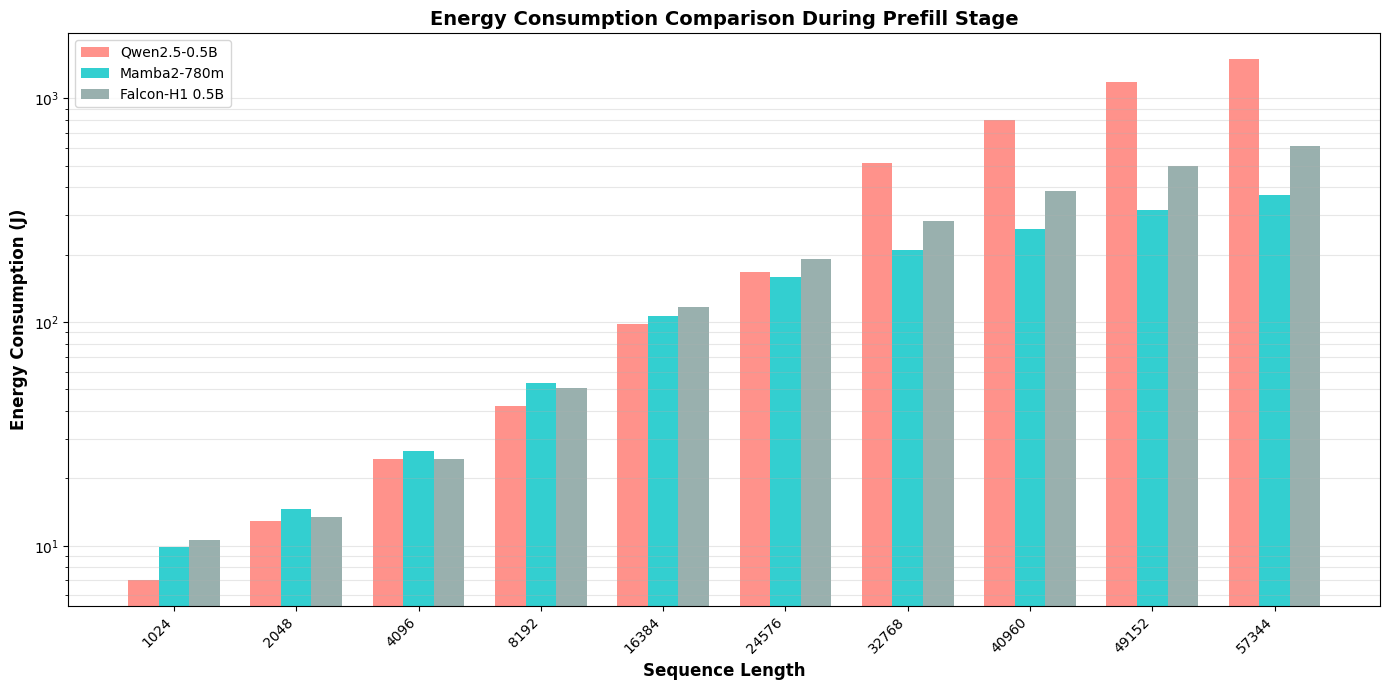

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Data
sequence_lengths = [1024, 2048, 4096, 8192, 16384, 24576, 32768, 40960, 49152, 57344]
qwen_energy = [7.058, 12.85, 24.54, 42.22, 98.26, 166.97, 512.40, 802.99, 1187.36, 1492.62]
mamba_energy = [9.881, 14.66, 26.45, 53.45, 106.02, 158.58, 209.18, 261.25, 315.32, 370.53]
falcon_energy = [10.609, 13.38, 24.37, 50.83, 116.36,191.40,283.51, 385.49, 496.90, 613.234]

# Create bar plot
x = np.arange(len(sequence_lengths))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 7))
bars1 = ax.bar(x - width, qwen_energy, width, label='Qwen2.5-0.5B', alpha=0.8, color='#FF776E')
bars2 = ax.bar(x, mamba_energy, width, label='Mamba2-780m', alpha=0.8, color='#00C3C5')
bars3 = ax.bar(x + width, falcon_energy, width, label='Falcon-H1 0.5B', alpha=0.8, color='#809d9a')

# Customize plot
ax.set_xlabel('Sequence Length', fontsize=12, fontweight='bold')
ax.set_ylabel('Energy Consumption (J)', fontsize=12, fontweight='bold')
ax.set_title('Energy Consumption Comparison During Prefill Stage', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(sequence_lengths, rotation=45, ha='right')
ax.set_yscale('log')
ax.legend()
ax.grid(axis='y', alpha=0.3, which='both')

plt.tight_layout()
plt.show()

## Publication Figure

Clean version of the same log-scale bar chart — axis ticks, labels, and legend removed for use as a paper figure. The output is saved to `energy_consumption.png` at 300 DPI.

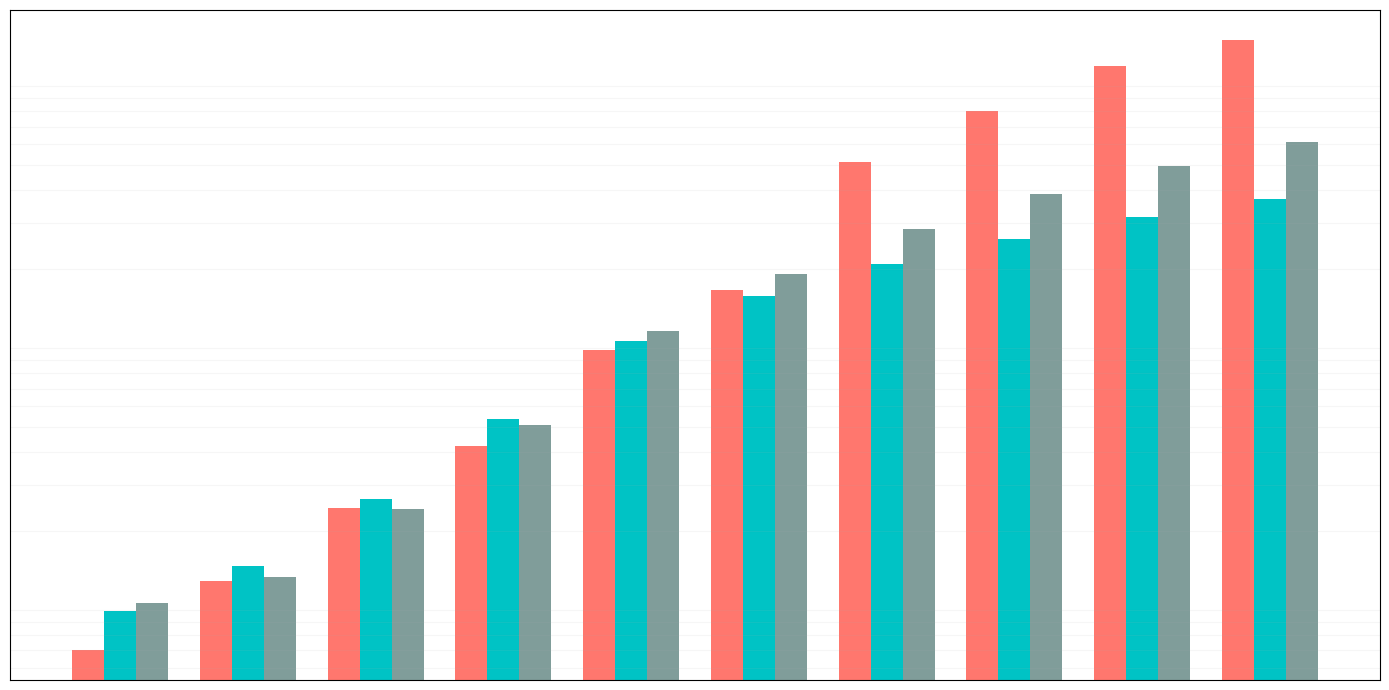

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Data
sequence_lengths = [1024, 2048, 4096, 8192, 16384, 24576, 32768, 40960, 49152, 57344]
qwen_energy = [7.058, 12.85, 24.54, 42.22, 98.26, 166.97, 512.40, 802.99, 1187.36, 1492.62]
mamba_energy = [9.881, 14.66, 26.45, 53.45, 106.02, 158.58, 209.18, 261.25, 315.32, 370.53]
falcon_energy = [10.609, 13.38, 24.37, 50.83, 116.36,191.40,283.51, 385.49, 496.90, 613.234]

# Create bar plot
x = np.arange(len(sequence_lengths))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 7))
bars1 = ax.bar(x - width, qwen_energy, width, label='Qwen2.5-0.5B', color='#FF776E')
bars2 = ax.bar(x, mamba_energy, width, label='Mamba2-780m', color='#00C3C5')
bars3 = ax.bar(x + width, falcon_energy, width, label='Falcon-H1 0.5B', color='#809d9a')

# Customize plot
# ax.set_xlabel('Sequence Length', fontsize=12, fontweight='bold')
# ax.set_ylabel('Energy Consumption (J)', fontsize=12, fontweight='bold')
# ax.set_title('Energy Consumption Comparison During Prefill Stage', fontsize=14, fontweight='bold')
# ax.set_xticks(x)
# ax.set_xticklabels(sequence_lengths, rotation=45, ha='right')
ax.set_yscale('log')
# ax.legend()
ax.grid(axis='y', alpha=0.1, which='both')
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
ax.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)

plt.tight_layout()
plt.savefig(f"{prof_dir}/energy_consumption.png", dpi=300, bbox_inches='tight')
plt.show()
